In [11]:
#importing the important librarires we will using 
# Name: SIDDIQUE UR REHMAN
#ID:16360
#pandas for data manipulation
import pandas as pd
#numpy for numerical operations
import numpy as np
#sklearn for  ML algorithms i-e decsionTree algorithm 
from sklearn.tree import DecisionTreeClassifier,plot_tree
#label encoder for conversion of categorical data into numeric
from sklearn.preprocessing import LabelEncoder
#matplotlib for visualization of the data
from matplotlib import pyplot as plt


In [9]:
#making a dataset in form of python dictionary in which feature name is key while the all columns values are in given in form of list
# Name: SIDDIQUE UR REHMAN
#ID:16360
data={
    "Outlook":["Sunny","Sunny","Overcast","Rainy","Rainy","Rainy","Overcast","Sunny","Sunny","Rainy","Sunny","Overcast","Overcast","Rainy"],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Windy': [False, True, False, False, False, True, True, False, False, False, True, True, False, True],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}
# changing into dataframe which is 2D and suitable for pandas operations
df=pd.DataFrame(data)
#for showing the data of choice giveing argument to head()
df.head(14)

,Outlook,Temperature,Humidity,Windy,PlayTennis
0,Sunny,Hot,High,False,No
1,Sunny,Hot,High,True,No
2,Overcast,Hot,High,False,Yes
3,Rainy,Mild,High,False,Yes
4,Rainy,Cool,Normal,False,Yes
5,Rainy,Cool,Normal,True,No
6,Overcast,Cool,Normal,True,Yes
7,Sunny,Mild,High,False,No
8,Sunny,Cool,Normal,False,Yes
9,Rainy,Mild,Normal,False,Yes


In [13]:
# Name: SIDDIQUE UR REHMAN
#ID:16360
lb_encoder=LabelEncoder()
#making copy of origianl data frame
df_encoded=df.copy()


for col in ['Outlook', 'Temperature', 'Humidity', 'PlayTennis']:
  df_encoded[col]=lb_encoder.fit_transform(df_encoded[col])



df_encoded.head()

,Outlook,Temperature,Humidity,Windy,PlayTennis
0,2,1,0,False,0
1,2,1,0,True,0
2,0,1,0,False,1
3,1,2,0,False,1
4,1,0,1,False,1


In [16]:
#changing wind column also to numeric
df_encoded['Windy']=df_encoded['Windy'].astype(int)
df_encoded.head(14)

,Outlook,Temperature,Humidity,Windy,PlayTennis
0,2,1,0,0,0
1,2,1,0,1,0
2,0,1,0,0,1
3,1,2,0,0,1
4,1,0,1,0,1
5,1,0,1,1,0
6,0,0,1,1,1
7,2,2,0,0,0
8,2,0,1,0,1
9,1,2,1,0,1


In [34]:
#Selecting Feature and output
X=df_encoded.drop(columns="PlayTennis")
y=df_encoded["PlayTennis"]

Text(0.5, 1.0, 'Proportion of YES/NO in data set')

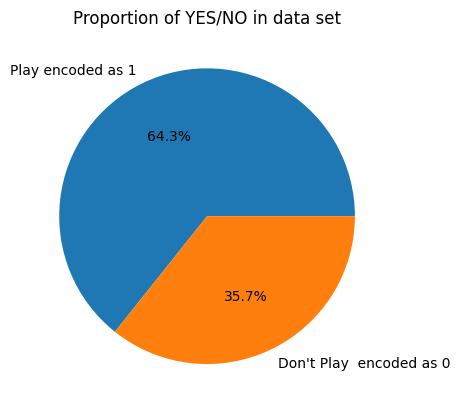

In [42]:
plt.pie(df_encoded["PlayTennis"].value_counts(),labels=["Play encoded as 1","Don't Play  encoded as 0"],autopct="%1.1f%%")
plt.title("Proportion of YES/NO in data set")

In [23]:
#Model trainnig
tree_model=DecisionTreeClassifier(max_depth=3)
tree_model.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


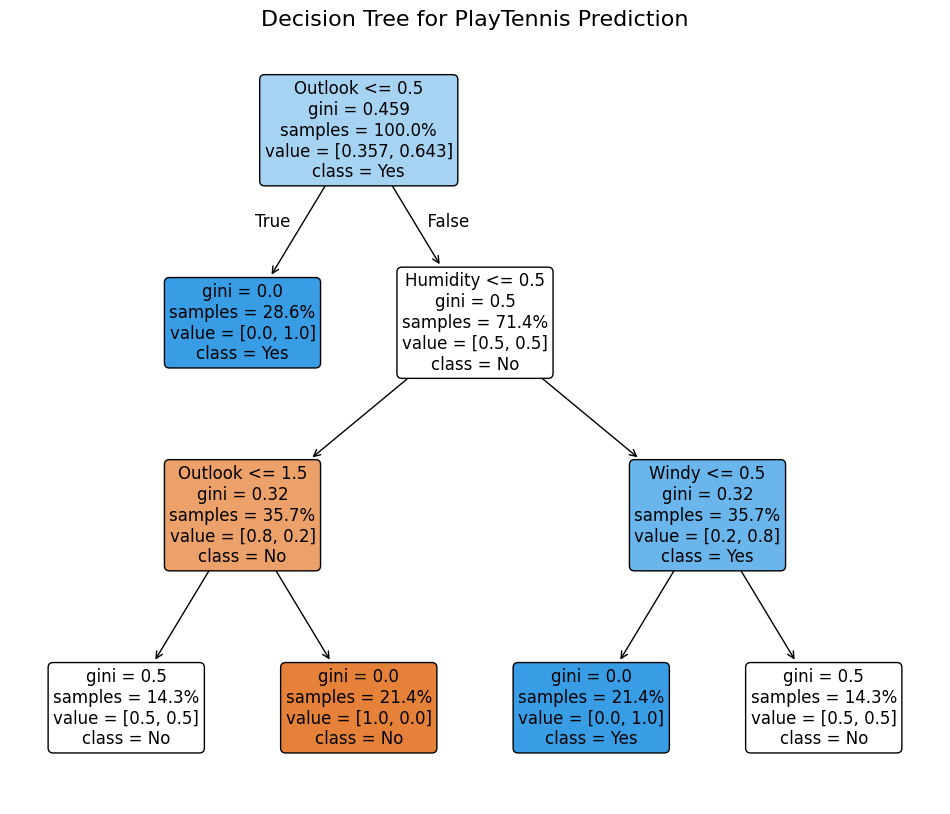

In [31]:
#tree plt
plt.figure(figsize=(12,10))
plot_tree(tree_model,
          feature_names=['Outlook', 'Temperature', 'Humidity', 'Windy'],
          class_names=['No', 'Yes'],
          filled=True,
          rounded=True,
          fontsize=12,
          proportion=True
         )
plt.title("Decision Tree for PlayTennis Prediction", fontsize=16)
plt.show()

In [33]:
# Manual encoding based on your training data mappings
# Check the mappings from your training
new_data = {
    'Outlook': 'Sunny',
    'Temperature': 'Cool', 
    'Humidity': 'High',
    'Windy': 'Strong'  # Note: Your training data has True/False, but we'll handle this
}

outlook_mapping = {'Overcast': 0, 'Rainy': 1, 'Sunny': 2}
temp_mapping = {'Cool': 0, 'Hot': 1, 'Mild': 2}
humidity_mapping = {'High': 0, 'Normal': 1}
windy_mapping = {'Weak': 0, 'Strong': 1}  # Assuming Strong=True, Weak=False

# Encode the new data
new_encoded = [
    outlook_mapping[new_data['Outlook']],
    temp_mapping[new_data['Temperature']],
    humidity_mapping[new_data['Humidity']],
    windy_mapping[new_data['Windy']]
]

print(f"Encoded new data: {new_encoded}")

# Make prediction
prediction = tree_model.predict([new_encoded])
prediction_proba = tree_model.predict_proba([new_encoded])

# Convert prediction back to original label
result = 'Yes' if prediction[0] == 1 else 'No'

print(f"\nPREDICTION RESULT: {result}")
print(f"Probability: No={prediction_proba[0][0]:.2f}, Yes={prediction_proba[0][1]:.2f}")

Encoded new data: [2, 0, 0, 1]

PREDICTION RESULT: No
Probability: No=1.00, Yes=0.00


C:\Users\Dell\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Dell\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
